In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error


In [2]:
df = pd.read_csv("Advertising.csv")

# Remove unnecessary column
df.drop("Unnamed: 0", axis=1, inplace=True)

# Check data
print(df.head())

      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3    9.3
3  151.5   41.3       58.5   18.5
4  180.8   10.8       58.4   12.9


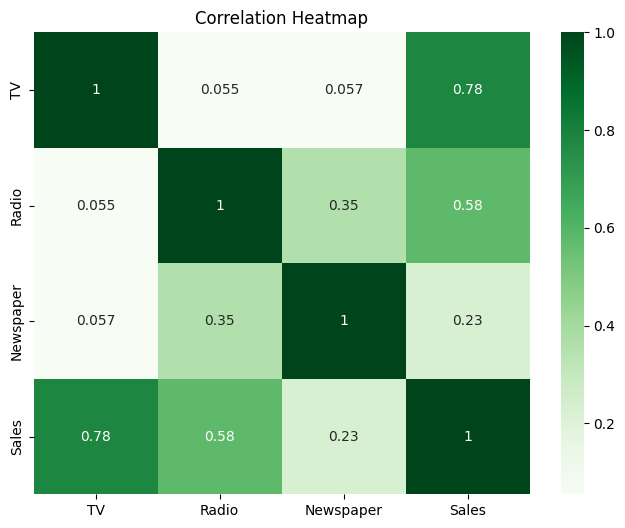

In [3]:
# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="Greens")
plt.title("Correlation Heatmap")
plt.show()


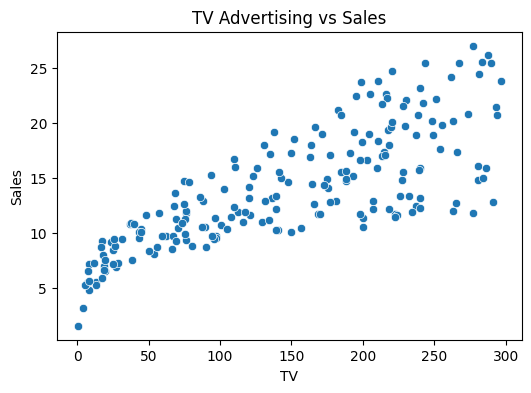

In [4]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="TV", y="Sales", data=df)
plt.title("TV Advertising vs Sales")
plt.show()


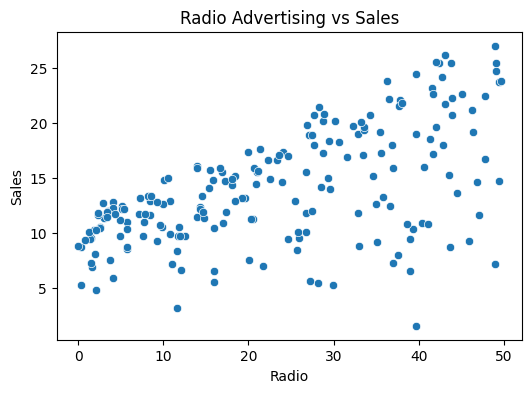

In [5]:
# Radio vs Sales
plt.figure(figsize=(6,4))
sns.scatterplot(x="Radio", y="Sales", data=df)
plt.title("Radio Advertising vs Sales")
plt.show()

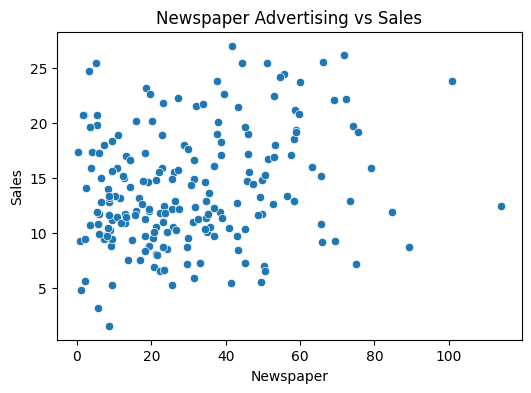

In [6]:
# Newspaper vs Sales
plt.figure(figsize=(6,4))
sns.scatterplot(x="Newspaper", y="Sales", data=df)
plt.title("Newspaper Advertising vs Sales")
plt.show()


In [9]:
# ------------------
# Model Building
# ------------------

X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)
# ------------------
# Model Evaluation
# ------------------

print("R2 Score:", r2_score(y_test, predictions))
print("MAE:", mean_absolute_error(y_test, predictions))


R2 Score: 0.899438024100912
MAE: 1.4607567168117603


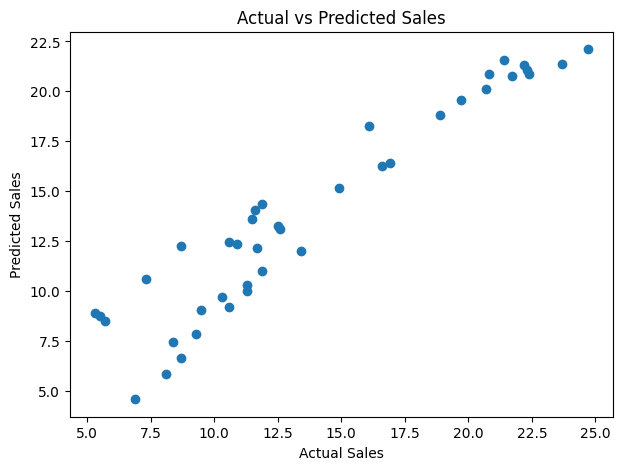

In [10]:
# ------------------
# Actual vs Predicted
# ------------------

plt.figure(figsize=(7,5))
plt.scatter(y_test, predictions)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()


In [11]:
# ------------------
# Predict New Sales
# ------------------

sample = [[150, 30, 20]]

prediction = model.predict(sample)

print("Predicted Sales:", prediction[0])

Predicted Sales: 15.419568872288718


c:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
